# 🧪 Fertilizer Recommendation Model Training

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.tree import DecisionTreeClassifier
print('Libraries loaded!')

Libraries loaded!


In [2]:
df = pd.read_csv('../datasets/Fertilizer_Prediction.csv')
print(f'Shape: {df.shape}')
df.head(5)

Shape: (3500, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,30,70,50,Loamy,Chickpea,75,52,30,20-20
1,27,76,49,Loamy,Chickpea,82,84,53,20-20
2,36,54,34,Alluvial,Groundnut,63,64,67,20-20
3,34,50,43,Alluvial,Rice,121,37,49,20-20
4,31,66,35,Red,Cotton,27,7,77,Urea


In [3]:
np.random.seed(42)
stages = ["Sowing", "Vegetative", "Flowering", "Harvesting"]
df['Stage'] = [stages[i % len(stages)] for i in range(len(df))]

crop_map_dataset = {
    'Paddy': 0, 'Rice': 0, 'Maize': 1, 'Cotton': 2, 'Chickpea': 3, 
    'Pigeon Peas': 4, 'Groundnut': 5, 'Wheat': 0, 'Sugarcane': 1, 
    'Barley': 1, 'Tobacco': 2, 'Oil seeds': 5, 'Pulses': 4, 'Millets': 1
}
df['crop_encoded'] = df['Crop Type'].map(crop_map_dataset).fillna(0).astype(int)

soil_map_dataset = {'Red': 0, 'Black': 1, 'Alluvial': 2, 'Clay': 3, 'Sandy': 4, 'Loamy': 5}
df['soil_encoded'] = df['Soil Type'].map(soil_map_dataset).fillna(5).astype(int)

stage_map_dataset = {"Sowing": 0, "Vegetative": 1, "Flowering": 2, "Harvesting": 3}
df['stage_encoded'] = df['Stage'].map(stage_map_dataset).fillna(0).astype(int)

# Aligned to FERTILIZER_LABELS in backend exactly
fert_name_map = {
    '10-26-26': 0,
    '14-35-14': 1,
    '17-17-17': 2,
    '20-20': 3,
    '28-28': 4,
    'DAP': 5,
    'Urea': 6,
    'MOP': 7
}
df['fert_encoded'] = df['Fertilizer Name'].map(fert_name_map).fillna(4).astype(int)

X = df[['crop_encoded', 'soil_encoded', 'Nitrogen', 'Phosphorous', 'Potassium', 'stage_encoded']].values
y = df['fert_encoded'].values
print(f'Features shape: {X.shape}, Targets: {len(np.unique(y))}')

Features shape: (3500, 6), Targets: 4


In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3)
dt_grid.fit(X_train, y_train)
dt_model = dt_grid.best_estimator_

print(f"Best parameters: {dt_grid.best_params_}")
print(f"Train Accuracy: {accuracy_score(y_train, dt_model.predict(X_train)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, dt_model.predict(X_test)):.4f}")

Best parameters: {'max_depth': 3, 'min_samples_split': 2}
Train Accuracy: 1.0000
Test Accuracy:  1.0000


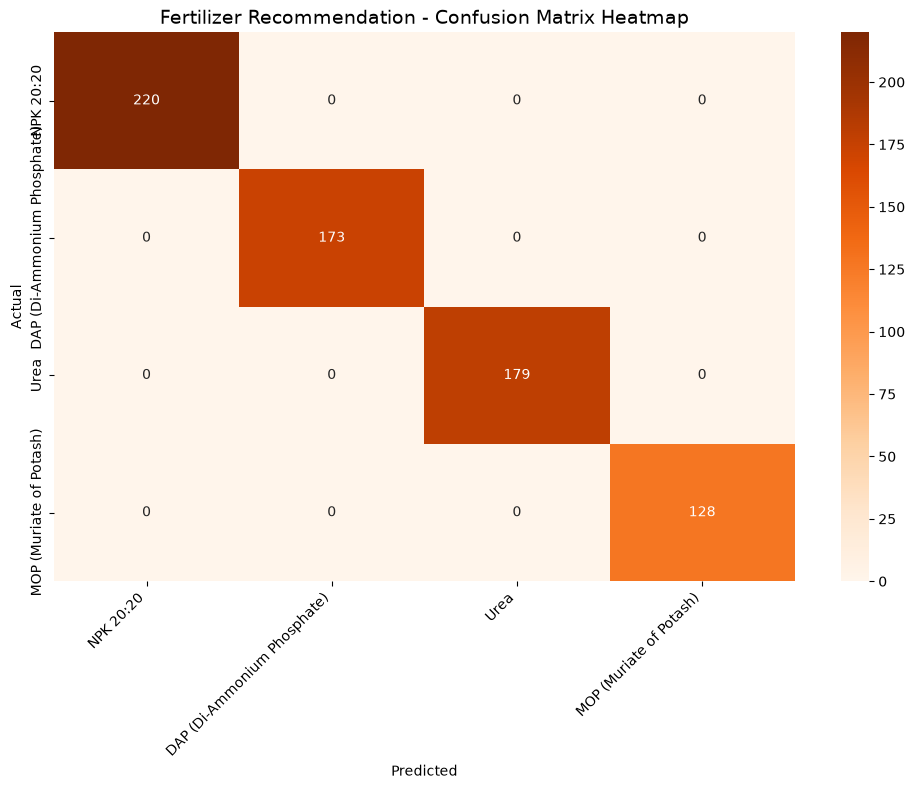

FERTILIZER CLASSIFICATION REPORT
                             precision    recall  f1-score   support

                  NPK 20:20       1.00      1.00      1.00       220
DAP (Di-Ammonium Phosphate)       1.00      1.00      1.00       173
                       Urea       1.00      1.00      1.00       179
    MOP (Muriate of Potash)       1.00      1.00      1.00       128

                   accuracy                           1.00       700
                  macro avg       1.00      1.00      1.00       700
               weighted avg       1.00      1.00      1.00       700



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Aligned labels to mapping indices 0-7
labels = ["NPK 10:26:26", "NPK 14:35:14", "NPK 17:17:17", "NPK 20:20", "NPK 28:28", "DAP (Di-Ammonium Phosphate)", "Urea", "MOP (Muriate of Potash)"]

unique_y = np.unique(np.concatenate([y_test, dt_model.predict(X_test)]))
display_labels = [labels[i] for i in unique_y]

cm = confusion_matrix(y_test, dt_model.predict(X_test))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=display_labels, yticklabels=display_labels)
plt.title('Fertilizer Recommendation - Confusion Matrix Heatmap', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fertilizer_confusion_matrix.png', dpi=150)
plt.show()

print("="*60)
print("FERTILIZER CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, dt_model.predict(X_test), target_names=display_labels))

In [6]:
os.makedirs('../../ml_models', exist_ok=True)
with open('../../ml_models/fertilizer_recommendation.pkl', 'wb') as f:
    pickle.dump(dt_model, f)
print('Successfully saved fertilizer model!')

Successfully saved fertilizer model!
